# Boosted-tree tuning and calibration

Notebook 3 established `boosted_numeric` as the winner on all four chronological folds. This notebook tunes that family, keeps `context_C3` as an interpretable comparison model, tests calibration without temporal leakage, and inspects the newest-session failure slices. It does not export a production artifact.

In [1]:
from __future__ import annotations

import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 2
TRAIN_ROWS_PER_FOLD = 2_000_000
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
VALIDATION_SESSIONS = ['20239', '20249', '20259', '20265']
RANDOM_STATE = 42

cache_paths = {s: CACHE_ROOT / f'{s}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for s in SESSION_ORDER}
missing = [str(path) for path in cache_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in cache_paths.items()}
print(f'Loaded {sum(map(len, session_samples.values())):,} cached rows')

Loaded 2,379,974 cached rows


## 1. Candidate specification

The boosted candidates vary tree size, learning rate, and L2 regularization around Notebook 3's winning configuration. `logistic_C3` is included as a control, not as the presumed production model. Every learned candidate uses the same deterministic training sample within a fold.

In [2]:
ALL_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
CONTEXT_CATEGORICAL = ['course_code', 'campus', 'term']
LOGISTIC_COLUMNS = ALL_NUMERIC + CONTEXT_CATEGORICAL

def boosted_model(*, learning_rate=0.05, max_iter=200, max_leaf_nodes=15, l2=1.0):
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), ALL_NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=learning_rate, max_iter=max_iter,
            max_leaf_nodes=max_leaf_nodes, l2_regularization=l2,
            random_state=RANDOM_STATE,
        )),
    ])

def logistic_model():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value=0)),
                ('scale', StandardScaler()),
            ]), ALL_NUMERIC),
            ('categorical', OneHotEncoder(handle_unknown='ignore', min_frequency=3), CONTEXT_CATEGORICAL),
        ])),
        ('model', LogisticRegression(C=3.0, solver='lbfgs', max_iter=300)),
    ])

CANDIDATES = {
    'boosted_leaf7_l2_1': lambda: boosted_model(max_leaf_nodes=7, l2=1.0),
    'boosted_leaf15_l2_0.3': lambda: boosted_model(max_leaf_nodes=15, l2=0.3),
    'boosted_leaf15_l2_1': lambda: boosted_model(max_leaf_nodes=15, l2=1.0),
    'boosted_leaf15_l2_3': lambda: boosted_model(max_leaf_nodes=15, l2=3.0),
    'boosted_leaf31_l2_1': lambda: boosted_model(max_leaf_nodes=31, l2=1.0),
    'boosted_slow_leaf15': lambda: boosted_model(learning_rate=0.03, max_iter=300, max_leaf_nodes=15, l2=1.0),
    'logistic_C3': logistic_model,
}

def feature_columns(name):
    return LOGISTIC_COLUMNS if name == 'logistic_C3' else ALL_NUMERIC

def weighted_ece(y, probability, weight, bins=10):
    groups = np.clip(np.digitize(probability, np.linspace(0, 1, bins + 1)) - 1, 0, bins - 1)
    total, error = weight.sum(), 0.0
    for group in range(bins):
        mask = groups == group
        if mask.any():
            observed = np.average(y[mask], weights=weight[mask])
            predicted = np.average(probability[mask], weights=weight[mask])
            error += weight[mask].sum() / total * abs(observed - predicted)
    return float(error)

def metrics(y, probability, weight, reference_probability):
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    brier = brier_score_loss(y, probability, sample_weight=weight)
    reference = np.full(len(y), reference_probability)
    reference_brier = brier_score_loss(y, reference, sample_weight=weight)
    return {
        'brier': brier, 'brier_skill': 1 - brier / reference_brier,
        'log_loss': log_loss(y, probability, sample_weight=weight, labels=[0, 1]),
        'ece_10': weighted_ece(y, probability, weight),
        'roc_auc': roc_auc_score(y, probability, sample_weight=weight),
    }

print(f'{len(CANDIDATES)} candidates')

7 candidates


## 2. Chronological tuning

The four validation sessions and two-million-row cap match Notebooks 2 and 3. Results checkpoint after each completed fit.

In [3]:
TUNING_PATH = CACHE_ROOT / 'boosted-tuning-canonical-v1.pkl'
tuning_results = pd.read_pickle(TUNING_PATH).to_dict('records') if TUNING_PATH.exists() else []
completed = {(row['validation_session'], row['candidate']) for row in tuning_results}

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train = pd.concat([session_samples[s] for s in SESSION_ORDER[:valid_index]], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=RANDOM_STATE)
    valid = session_samples[valid_session]
    y, weight = valid['cleared'].to_numpy(), valid['model_weight'].to_numpy()
    reference_probability = np.average(train['cleared'], weights=train['model_weight'])
    print(f'Fold {valid_session}: {len(model_train):,} training rows; {len(valid):,} validation rows', flush=True)

    for candidate_number, (name, factory) in enumerate(CANDIDATES.items(), start=1):
        key = (valid_session, name)
        if key in completed:
            print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {name}: fitting', flush=True)
        columns = feature_columns(name)
        model = factory()
        model.fit(model_train[columns], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = model.predict_proba(valid[columns])[:, 1]
        tuning_results.append({
            'validation_session': valid_session, 'candidate': name,
            **metrics(y, probability, weight, reference_probability),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(tuning_results).to_pickle(TUNING_PATH)
        completed.add(key)
        print(f'  complete in {tuning_results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

tuning_scores = pd.DataFrame(tuning_results).sort_values(['validation_session', 'brier'])
tuning_summary = tuning_scores.groupby('candidate').agg(
    mean_brier=('brier', 'mean'), worst_brier=('brier', 'max'),
    mean_skill=('brier_skill', 'mean'), mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'), mean_auc=('roc_auc', 'mean'),
    total_minutes=('seconds', lambda values: values.sum() / 60),
).sort_values(['mean_brier', 'mean_ece'])
display(tuning_summary)
display(tuning_scores.pivot(index='validation_session', columns='candidate', values='brier'))

Fold 20239: 579,974 training rows; 300,000 validation rows
[1/4, 1/7] boosted_leaf7_l2_1: fitting
  complete in 0.0 min
[1/4, 2/7] boosted_leaf15_l2_0.3: fitting
  complete in 0.0 min
[1/4, 3/7] boosted_leaf15_l2_1: fitting
  complete in 0.0 min
[1/4, 4/7] boosted_leaf15_l2_3: fitting
  complete in 0.0 min
[1/4, 5/7] boosted_leaf31_l2_1: fitting
  complete in 0.0 min
[1/4, 6/7] boosted_slow_leaf15: fitting
  complete in 0.0 min
[1/4, 7/7] logistic_C3: fitting
  complete in 0.0 min
Fold 20249: 1,179,974 training rows; 300,000 validation rows
[2/4, 1/7] boosted_leaf7_l2_1: fitting
  complete in 0.1 min
[2/4, 2/7] boosted_leaf15_l2_0.3: fitting
  complete in 0.1 min
[2/4, 3/7] boosted_leaf15_l2_1: fitting
  complete in 0.1 min
[2/4, 4/7] boosted_leaf15_l2_3: fitting
  complete in 0.1 min
[2/4, 5/7] boosted_leaf31_l2_1: fitting
  complete in 0.1 min
[2/4, 6/7] boosted_slow_leaf15: fitting
  complete in 0.1 min
[2/4, 7/7] logistic_C3: fitting
  complete in 0.1 min
Fold 20259: 1,779,974 trai

,mean_brier,worst_brier,mean_skill,mean_log_loss,mean_ece,mean_auc,total_minutes
candidate,,,,,,,
boosted_leaf15_l2_0.3,0.050783,0.056060,0.488048,0.173352,0.025499,0.945047,0.372954
boosted_leaf31_l2_1,0.050838,0.055893,0.487555,0.174255,0.025369,0.944697,0.426979
boosted_leaf15_l2_1,0.050848,0.056106,0.487395,0.174061,0.025801,0.944467,0.392254
boosted_slow_leaf15,0.050912,0.056076,0.486771,0.174227,0.025536,0.944189,0.488123
boosted_leaf7_l2_1,0.051074,0.056222,0.485250,0.174202,0.026130,0.944249,0.348078
boosted_leaf15_l2_3,0.051075,0.056180,0.485183,0.175402,0.026091,0.943634,0.388919
logistic_C3,0.063165,0.069600,0.366374,0.211897,0.033606,0.922966,0.390261


candidate,boosted_leaf15_l2_0.3,boosted_leaf15_l2_1,boosted_leaf15_l2_3,boosted_leaf31_l2_1,boosted_leaf7_l2_1,boosted_slow_leaf15,logistic_C3
validation_session,,,,,,,
20239,0.048965,0.048963,0.049315,0.049275,0.048979,0.049150,0.063339
20249,0.053824,0.053856,0.054255,0.054047,0.054296,0.053955,0.069600
20259,0.044283,0.044468,0.044549,0.044139,0.044797,0.044466,0.060675
20265,0.056060,0.056106,0.056180,0.055893,0.056222,0.056076,0.059046


## 3. Honest calibration comparison

The best boosted candidate by mean Brier is calibrated without leakage. For each validation session, the immediately preceding session fits the calibrator. The base model sees only earlier sessions.

In [4]:
boosted_summary = tuning_summary.loc[tuning_summary.index.str.startswith('boosted_')]
chosen_candidate = boosted_summary.index[0]
chosen_factory = CANDIDATES[chosen_candidate]
print(f'Calibrating {chosen_candidate}')

def logit(probability):
    probability = np.clip(probability, 1e-6, 1 - 1e-6)
    return np.log(probability / (1 - probability)).reshape(-1, 1)

calibration_results = []
recent_predictions = {}
for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    calibration_session = SESSION_ORDER[valid_index - 1]
    base_sessions = SESSION_ORDER[:valid_index - 1]
    base_train = pd.concat([session_samples[s] for s in base_sessions], ignore_index=True)
    model_train = base_train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(base_train)), random_state=RANDOM_STATE)
    calibration = session_samples[calibration_session]
    valid = session_samples[valid_session]
    print(f'[{fold_number}/4] base={base_sessions} calibrate={calibration_session} validate={valid_session}', flush=True)

    base_model = chosen_factory()
    base_model.fit(model_train[ALL_NUMERIC], model_train['cleared'], model__sample_weight=model_train['model_weight'])
    calibration_probability = base_model.predict_proba(calibration[ALL_NUMERIC])[:, 1]
    raw_probability = base_model.predict_proba(valid[ALL_NUMERIC])[:, 1]

    platt = LogisticRegression(C=1e6, solver='lbfgs')
    platt.fit(logit(calibration_probability), calibration['cleared'], sample_weight=calibration['model_weight'])
    platt_probability = platt.predict_proba(logit(raw_probability))[:, 1]

    isotonic = IsotonicRegression(out_of_bounds='clip')
    isotonic.fit(calibration_probability, calibration['cleared'], sample_weight=calibration['model_weight'])
    isotonic_probability = isotonic.predict(raw_probability)

    y, weight = valid['cleared'].to_numpy(), valid['model_weight'].to_numpy()
    reference_probability = np.average(base_train['cleared'], weights=base_train['model_weight'])
    for method, probability in [('raw', raw_probability), ('platt', platt_probability), ('isotonic', isotonic_probability)]:
        calibration_results.append({
            'validation_session': valid_session, 'method': method,
            **metrics(y, probability, weight, reference_probability),
        })
        if valid_session == VALIDATION_SESSIONS[-1]:
            recent_predictions[method] = probability
    del base_train, model_train, base_model
    gc.collect()

calibration_scores = pd.DataFrame(calibration_results).sort_values(['validation_session', 'brier'])
calibration_summary = calibration_scores.groupby('method').agg(
    mean_brier=('brier', 'mean'), worst_brier=('brier', 'max'),
    mean_skill=('brier_skill', 'mean'), mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
).sort_values(['mean_brier', 'mean_ece'])
display(calibration_scores)
display(calibration_summary)

Calibrating boosted_leaf15_l2_0.3
[1/4] base=['20229'] calibrate=20235 validate=20239
[2/4] base=['20229', '20235', '20239'] calibrate=20245 validate=20249
[3/4] base=['20229', '20235', '20239', '20245', '20249'] calibrate=20255 validate=20259
[4/4] base=['20229', '20235', '20239', '20245', '20249', '20255'] calibrate=20259 validate=20265


,validation_session,method,brier,brier_skill,log_loss,ece_10,roc_auc
0,20239,raw,0.044190,0.529914,0.149011,0.012313,0.958340
1,20239,platt,0.049960,0.468534,0.167793,0.038256,0.958340
2,20239,isotonic,0.050476,0.463037,0.166417,0.036203,0.955650
3,20249,raw,0.053007,0.533898,0.173747,0.030404,0.959435
4,20249,platt,0.054570,0.520161,0.177410,0.034229,0.959435
5,20249,isotonic,0.054744,0.518627,0.178101,0.033776,0.958616
6,20259,raw,0.044076,0.560875,0.146786,0.021347,0.963942
7,20259,platt,0.044214,0.559500,0.146817,0.017998,0.963942
8,20259,isotonic,0.044533,0.556330,0.146254,0.018060,0.963841
11,20265,isotonic,0.053801,0.409024,0.203324,0.016606,0.907726


,mean_brier,worst_brier,mean_skill,mean_ece,mean_auc
method,,,,,
raw,0.049251,0.055729,0.503132,0.024463,0.947477
platt,0.050639,0.054570,0.489268,0.027016,0.947477
isotonic,0.050888,0.054744,0.486755,0.026161,0.946458


## 4. Reliability and newest-session error slices

The selected calibration method is the method with the lowest four-fold mean Brier. The tables below expose probability, rank, deadline, campus, and term failures that averages can hide.

probability_band


,probability_band,rows,predicted,observed,absolute_gap,brier
0,"(-0.001, 0.1]",1515,0.019302,0.000840,0.018462,0.001871
1,"(0.1, 0.2]",2471,0.152876,0.033441,0.119435,0.045838
2,"(0.2, 0.3]",4049,0.247421,0.133132,0.114288,0.126353
3,"(0.3, 0.4]",4717,0.355044,0.211496,0.143548,0.189284
4,"(0.4, 0.5]",5616,0.451566,0.324559,0.127007,0.234962
5,"(0.5, 0.6]",7489,0.550360,0.387955,0.162405,0.260478
6,"(0.6, 0.7]",9459,0.652872,0.557036,0.095837,0.254845
7,"(0.7, 0.8]",12913,0.753454,0.672639,0.080814,0.226153
8,"(0.8, 0.9]",25115,0.858062,0.772313,0.085749,0.182506
9,"(0.9, 1.0]",226656,0.987553,0.964723,0.022831,0.033398


ratio_band


,ratio_band,rows,predicted,observed,absolute_gap,brier
0,"(-inf, 0.05]",56861,0.966732,0.942159,0.024573,0.026647
1,"(0.05, 0.1]",52215,0.959266,0.926295,0.032971,0.050376
2,"(0.1, 0.2]",72959,0.914365,0.872161,0.042204,0.084205
3,"(0.2, 0.3]",44838,0.865795,0.837905,0.027890,0.096723
4,"(0.3, inf]",73127,0.752559,0.672221,0.080337,0.150078


days_band


,days_band,rows,predicted,observed,absolute_gap,brier
0,"(-inf, 7.0]",8173,0.511781,0.379034,0.132747,0.138135
1,"(7.0, 14.0]",23788,0.863687,0.823717,0.039970,0.101314
2,"(14.0, 30.0]",82301,0.948281,0.903243,0.045038,0.069340
3,"(30.0, 60.0]",91515,0.974748,0.948689,0.026059,0.044411
4,"(60.0, inf]",94223,0.990529,0.987848,0.002681,0.009563


campus


,campus,rows,predicted,observed,absolute_gap,brier
0,ARTSC,156275,0.939801,0.908334,0.031467,0.050258
1,ERIN,60255,0.949358,0.945691,0.003667,0.030112
2,SCAR,83470,0.909906,0.850781,0.059125,0.082388


term


,term,rows,predicted,observed,absolute_gap,brier
0,fall,135703,0.921743,0.900440,0.021303,0.051192
1,full_year,52439,0.910893,0.885731,0.025162,0.059938
2,winter,111858,0.961530,0.904652,0.056878,0.059560


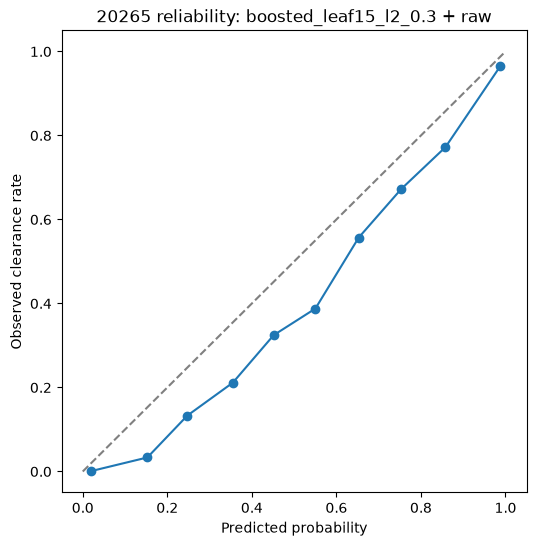

In [5]:
chosen_method = calibration_summary.index[0]
recent = session_samples[VALIDATION_SESSIONS[-1]].copy()
recent['probability'] = recent_predictions[chosen_method]
recent['ratio_band'] = pd.cut(recent['position_to_capacity'], [-np.inf, .05, .10, .20, .30, np.inf])
recent['days_band'] = pd.cut(recent['days_to_deadline'], [-np.inf, 7, 14, 30, 60, np.inf])
recent['probability_band'] = pd.cut(recent['probability'], np.linspace(0, 1, 11), include_lowest=True)

def slice_table(column):
    rows = []
    for label, group in recent.groupby(column, observed=True):
        if len(group) < 100:
            continue
        weight = group['model_weight'].to_numpy()
        predicted = np.average(group['probability'], weights=weight)
        observed = np.average(group['cleared'], weights=weight)
        rows.append({
            column: label, 'rows': len(group), 'predicted': predicted,
            'observed': observed, 'absolute_gap': abs(predicted - observed),
            'brier': brier_score_loss(group['cleared'], group['probability'], sample_weight=weight),
        })
    return pd.DataFrame(rows)

for column in ['probability_band', 'ratio_band', 'days_band', 'campus', 'term']:
    print(column)
    display(slice_table(column))

reliability = slice_table('probability_band')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.plot(reliability['predicted'], reliability['observed'], marker='o')
ax.set(
    xlabel='Predicted probability', ylabel='Observed clearance rate',
    title=f'{VALIDATION_SESSIONS[-1]} reliability: {chosen_candidate} + {chosen_method}',
)
plt.show()

## 5. Findings and decision

All tuning and calibration comparisons used chronological holdouts and identical deterministic training rows within each fold.

### Tree tuning

- `boosted_leaf15_l2_0.3` had the best four-fold mean Brier at **0.05078**, with **0.02550 mean ECE** and **0.94505 mean ROC AUC**.
- The boosted configurations were tightly grouped. Mean Brier ranged only from **0.05078** to **0.05108**, so the result does not support a large or fragile tree-complexity claim.
- `boosted_leaf31_l2_1` had the best worst-fold Brier at **0.05589**, but its mean Brier was slightly worse at **0.05084**.
- The logistic control remained materially behind at **0.06317 mean Brier**.

### Calibration

- Raw probabilities were best overall at **0.04925 mean Brier**, **0.02446 mean ECE**, and **0.94748 mean ROC AUC**.
- Platt and isotonic calibration improved the newest `20265` fold, but both worsened the earlier folds and the four-fold average.
- No global calibrator is selected. The production candidate should retain raw boosted-tree probabilities.

### Remaining failure slices

- Within seven days of the deadline, the model predicted **51.2%** clearance while **37.9%** cleared, a **13.3-point overprediction**.
- Ranks above 30% of capacity were overpredicted by **8.0 points**.
- Winter offerings were overpredicted by **5.7 points**, and Scarborough offerings by **5.9 points**.
- Predictions from 10% through 60% were overconfident by roughly **11–16 points**.

### Decision

Carry `boosted_leaf15_l2_0.3` with raw probabilities into Notebook 5. Notebook 5 should test targeted deadline, rank, term, and campus features against this unchanged control. It should retain a new feature only when it improves chronological Brier and the relevant failure slice without damaging calibration elsewhere.